In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/Data_Engineering_Internship/student_performance.csv')

conn = sqlite3.connect('college.db')
df.to_sql('students', conn, index=False, if_exists='replace')

print('Data loaded successfully!')
print(f'Shape: {df.shape}')
df.head()

Data loaded successfully!
Shape: (30, 13)


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


QUESTION 1-Find the average programming score for female students only.

In [2]:
query1 = """
SELECT AVG(programming_score) AS avg_programming_score
FROM students
WHERE gender = 'Female'
"""

result1 = pd.read_sql_query(query1, conn)
print(result1)

   avg_programming_score
0                   70.2


QUESTION 2-Difference between WHERE and HAVING – one example each.

In [3]:
query2a = """
SELECT name, programming_score
FROM students
WHERE programming_score > 80
"""

result2a = pd.read_sql_query(query2a, conn)
print('Students with programming score > 80:')
print(result2a.head())

Students with programming score > 80:
           name  programming_score
0  Aarav Sharma                 91
1    Arjun Nair                 95
2   Divya Singh                 93
3    Ananya Das                 97
4    Suresh Rao                 88


In [4]:
query2b = """
SELECT department, AVG(programming_score) AS avg_score
FROM students
GROUP BY department
HAVING AVG(programming_score) > 75
"""

result2b = pd.read_sql_query(query2b, conn)
print('Departments with avg programming score > 75:')
print(result2b)

Departments with avg programming score > 75:
         department  avg_score
0  Computer Science  89.230769


QUESTION 3-Find all departments where the average attendance is above 85%

In [6]:
query3 = """
SELECT department, AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85
ORDER BY avg_attendance DESC
"""

result3 = pd.read_sql_query(query3, conn)
print('Departments with average attendance above 85%:')
print(result3)

Departments with average attendance above 85%:
         department  avg_attendance
0  Computer Science       90.692308


QUESTION 4-What does `pd.read_sql_query()` return? What two arguments does it require?

In [7]:
result4 = pd.read_sql_query('SELECT * FROM students LIMIT 5', conn)

print(f'Type returned: {type(result4)}')
print(f'Shape: {result4.shape}')
result4

Type returned: <class 'pandas.core.frame.DataFrame'>
Shape: (5, 13)


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


QUESTION 5-Modify Chart 1 (bar chart) to show average PROGRAMMING scores instead of math scores.

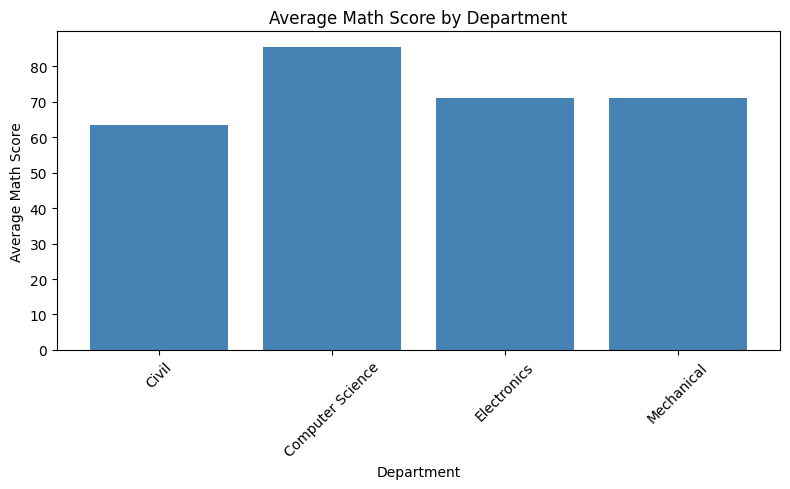

In [8]:
query_math = """
SELECT department, AVG(math_score) AS avg_math
FROM students
GROUP BY department
"""
math_df = pd.read_sql_query(query_math, conn)

plt.figure(figsize=(8, 5))
plt.bar(math_df['department'], math_df['avg_math'], color='steelblue')
plt.title('Average Math Score by Department')
plt.xlabel('Department')
plt.ylabel('Average Math Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

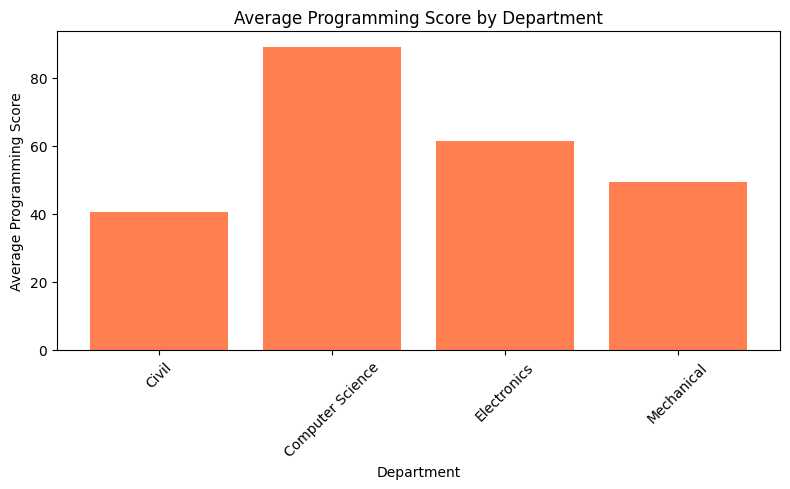

In [9]:
query_prog = """
SELECT department, AVG(programming_score) AS avg_programming
FROM students
GROUP BY department
"""
prog_df = pd.read_sql_query(query_prog, conn)

plt.figure(figsize=(8, 5))
plt.bar(prog_df['department'], prog_df['avg_programming'], color='coral')
plt.title('Average Programming Score by Department')
plt.xlabel('Department')
plt.ylabel('Average Programming Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()